# Setup

In [1]:
# Imports for Training #

import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, ReLU, MaxPool2D, BatchNormalization, Flatten, Dense
from tensorflow.keras.models import Model

2026-04-09 00:54:49.720846: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Constants #

GAUSSIAN_X = 48
GAUSSIAN_Y = 48

MIN_STD_X = 5
MAX_STD_X = 11

MIN_STD_Y = 5
MAX_STD_Y = 11

MIN_THETA = 0
MAX_THETA = np.pi

MIN_INTENSITY = 0.2
MAX_INTENSITY = 0.8

In [3]:
# Util Functions #

def img_gen(VERBOSE: bool = False) -> tuple:

    # Randomize params
    center_x = GAUSSIAN_X // 2
    center_y = GAUSSIAN_Y // 2

    std_x = np.random.randint(low=MIN_STD_X, high=MAX_STD_X)
    std_y = np.random.randint(low=MIN_STD_Y, high=MAX_STD_Y)
    theta = np.random.randint(low=MIN_THETA, high=MAX_THETA)
    
    intensity = np.random.uniform(low=MIN_INTENSITY, high=MAX_INTENSITY)
        
    # Generate Gaussian
    params = (center_x, center_y, std_x, std_y, theta)
    gaussian = (gaussian_gen(center_x, center_y, std_x, std_y, theta) * intensity * 255).astype(np.uint8)

    # DEBUG
    if VERBOSE:
        # print(f"[Image Shape]: {str(img.shape)}")
        # print(f"[Label Shape]: {str(label.shape)}")
        for param in params:
            print(
            f"[(c_x, c_y)]: ({param[0]:<3}, {param[1]:<3}) "
            f"[(s_x, s_y)]: ({param[2]:<3}, {param[3]:<3}) "
            f"[Theta]: {param[4]:.2f} "
            f"[I]: {param[5]:.2f} "
            )

    return (gaussian, params)

def gaussian_gen(center_x: int, center_y: int, std_x: int, std_y: int, theta: float) -> np.ndarray:
    
    X = np.arange(0, GAUSSIAN_X, 1)
    Y = np.arange(0, GAUSSIAN_Y, 1)
    X, Y = np.meshgrid(X, Y)

    cos_theta_sqrd = np.pow(np.cos(theta),2)
    sin_theta_sqrd = np.pow(np.sin(theta),2)
    sin_cos_theta = np.sin(theta) * np.cos(theta)

    std_x_sqrd = np.pow(std_x, 2)
    std_y_sqrd = np.pow(std_y, 2)

    a = (cos_theta_sqrd) / (2 * std_x_sqrd) + (sin_theta_sqrd) / (2 * std_y_sqrd)
    b = -1 * (sin_cos_theta) / (2 * std_x_sqrd) + (sin_cos_theta) / (2 * std_y_sqrd)
    c = (sin_theta_sqrd) / (2 * std_x_sqrd) + (cos_theta_sqrd) / (2 * std_y_sqrd)

    gaussian = np.exp(-(a * (X - center_x)**2 + 2*b * (X - center_x) * (Y - center_y) + c * (Y - center_y)**2))

    return np.expand_dims(gaussian, -1)

def img_visualization_one(img: np.ndarray, params: np.ndarray) -> None:
    
    rgb_image = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    if params != None:
        print(
        f"[(c_x, c_y)]: ({params[0]:<3}, {params[1]:<3}) "
        f"[(s_x, s_y)]: ({params[2]:<3}, {params[3]:<3}) "
        f"[Theta]: {params[4]:.2f} "
        )
    
    plt.imshow(rgb_image)

[(c_x, c_y)]: (24 , 24 ) [(s_x, s_y)]: (7  , 10 ) [Theta]: 2.00 


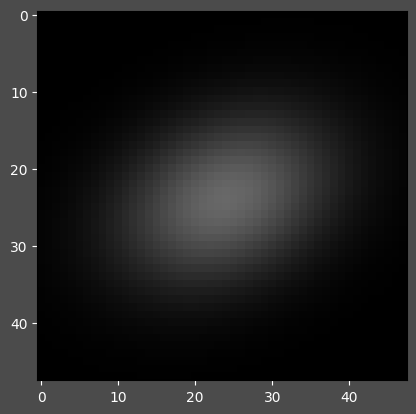

In [5]:
# Test Util Functions #

img, params = img_gen()
img_visualization_one(img, params)

In [6]:
# Generate Training Dataset #
SAMPLE_COUNT = 1000

img_arr = []
label_arr = []

def process_image():
    img, label = img_gen()
    return img, label

img_arr = []
label_arr = []
with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_image) for _ in range(SAMPLE_COUNT)]
    for future in tqdm(as_completed(futures), total=SAMPLE_COUNT):
        img, label = future.result()
        img_arr.append(img.astype(np.float32) / 256) # Normalize values to [0, 1)
        label_arr.append(label)

img_arr = np.array(img_arr).astype(np.float32)
label_arr = np.array(label_arr).astype(np.float32)

print(f'[Images Shape]: {img_arr.shape}')
print(f'[Labels Shape]: {label_arr.shape}')

100%|██████████| 1000/1000 [00:00<00:00, 6211.47it/s]

[Images Shape]: (1000, 48, 48, 1)
[Labels Shape]: (1000, 5)


# Training

In [7]:
# Convert Data to tf DataSet #
BATCH_SIZE = 25

dataset = tf.data.Dataset.from_tensor_slices((img_arr, label_arr))
dataset = dataset.shuffle(SAMPLE_COUNT, reshuffle_each_iteration=True)
dataset = dataset.batch(BATCH_SIZE)

I0000 00:00:1775721301.799590   10600 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6601 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070, pci bus id: 0000:01:00.0, compute capability: 7.5


In [8]:
# Model Architecture # 

input_layer = Input(shape=(GAUSSIAN_X, GAUSSIAN_Y, 1), name='InputLayer')

x = Conv2D(filters=6, kernel_size=3, strides=1, padding='valid', kernel_initializer='lecun_uniform')(input_layer)
x = BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-03)(x)
x = ReLU()(x)
x = MaxPool2D(pool_size=4, strides=4)(x)

x = Conv2D(filters=8, kernel_size=3, strides=1, padding='valid', kernel_initializer='lecun_uniform')(x)
x = BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-03)(x)
x = ReLU()(x)
x = MaxPool2D(pool_size=2, strides=2)(x)

x = Conv2D(filters=10, kernel_size=3, strides=1, padding='valid', kernel_initializer='lecun_uniform')(x)
x = BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-03)(x)
x = ReLU()(x)
x = MaxPool2D(pool_size=2, strides=2)(x)

x = Flatten()(x)
x = Dense(units=15, activation='relu')(x)
x = Dense(units=10, activation='relu')(x)

x_params = Dense(units=5, activation='linear')(x)

gaussian_tf = Model(inputs=input_layer, outputs=x_params, name='gaussian')

In [9]:
# Tensorflow Functions #

scaling_arr = np.array([48.0, 48.0, 24.0, 24.0, np.pi/2], dtype=np.float32)

# huber loss
def dice_loss(y_true, y_pred, delta=0.5):

    weights = tf.constant([3.0, 1.0, 2.0, 2.0, 0.1], dtype=tf.float32)
    y_pred = y_pred * scaling_arr + 1e-8
    diff = y_true - y_pred
    abs_diff = tf.abs(diff)

    quadratic = tf.minimum(abs_diff, delta)
    linear = abs_diff - quadratic
    huber_loss = 0.5 * tf.square(quadratic) + delta * linear

    weighted_loss = weights * huber_loss
    return tf.reduce_mean(weighted_loss)

In [ ]:
# Train or Load #
TRAIN_MODEL = True
LOAD_MODEL = False

MODEL_NAME = '[Gaussian]_[Generated]_[48].keras'
NUM_EPOCHS = 100

if (TRAIN_MODEL and LOAD_MODEL):
    print("Are you sure you want to do both?")

elif (TRAIN_MODEL):
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.01,
        decay_steps=NUM_EPOCHS,
        decay_rate=0.9)

    adam_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    gaussian_tf.compile(optimizer=adam_optimizer, loss=dice_loss, run_eagerly=True)

    for epoch in range(NUM_EPOCHS):
        running_loss = 0.0
        
        for batch in tqdm(dataset):
            with tf.GradientTape() as tape:
                prediction = gaussian_tf(batch[0])
                loss = dice_loss(batch[1], prediction)  # Compute the loss
            grads = tape.gradient(loss, gaussian_tf.trainable_variables)
            adam_optimizer.apply_gradients(zip(grads, gaussian_tf.trainable_variables))
            running_loss += loss.numpy()
            
        average_loss = running_loss / len(dataset)
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {average_loss}")

elif (LOAD_MODEL):
    gaussian_tf = tf.keras.models.load_model(
        f'/mnt/Research/Rheed-Gaussian/Models/{MODEL_NAME}',
        custom_objects={"dice_loss": dice_loss}
)

gaussian_tf.summary()

Model: "gaussian"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ InputLayer (InputLayer)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 46, 46, 6)      │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 6)      │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 46, 46, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 9, 9, 8)        │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 9, 9, 8)        │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 9, 9, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 2, 2, 10)       │           730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2, 2, 10)       │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 2, 2, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │           165 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            55 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,023 (19.62 KB)

 Trainable params: 1,658 (6.48 KB)

 Non-trainable params: 48 (192.00 B)

 Optimizer params: 3,317 (12.96 KB)

In [11]:
# Save Model #
SAVE_MODEL = True

if (SAVE_MODEL):
    gaussian_tf.save(f'/mnt/Research/Rheed-Gaussian/Models/{MODEL_NAME}')


In [12]:
# Create Validation Dataset #
VAL_COUNT = 100

img_arr_val = []
label_arr_val = []

def process_image():
    img, label = img_gen()
    return img, label

with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_image) for _ in range(VAL_COUNT)]
    for future in tqdm(as_completed(futures), total=VAL_COUNT):
        img, label = future.result()
        img_arr_val.append(img.astype(np.float32) / 256) # Normalize values to [0, 1)
        label_arr_val.append(label)

img_arr_val = np.array(img_arr_val).astype(np.float32)
label_arr_val = np.array(label_arr_val).astype(np.float32)

predictions_tf = gaussian_tf(img_arr_val) * scaling_arr

print(f'[Images Shape]: {img_arr_val.shape}')
print(f'[Prediction Shape]: {predictions_tf.shape}')

100%|██████████| 100/100 [00:00<00:00, 125917.26it/s]
/mnt/Research/Rheed-Gaussian/.venv/lib/python3.13/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['InputLayer']
Received: inputs=Tensor(shape=(100, 48, 48, 1))
  warnings.warn(msg)
2026-04-09 00:55:32.086524: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801


[Images Shape]: (100, 48, 48, 1)
[Prediction Shape]: (100, 5)


In [19]:
# Visual Validation #
index = np.random.randint(low=0, high=VAL_COUNT)

print(
    f"[(c_x, c_y)]: ({label_arr_val[index][0]:<3}, {label_arr_val[index][1]:<3}) "
    f"[(s_x, s_y)]: ({label_arr_val[index][2]:<3}, {label_arr_val[index][3]:<3}) "
    f"[Theta]: {label_arr_val[index][4]:.2f} "
)

print(
    f"[(c_x, c_y)]: ({predictions_tf[index][0]:<3}, {predictions_tf[index][1]:<3}) "
    f"[(s_x, s_y)]: ({predictions_tf[index][2]:<3}, {predictions_tf[index][3]:<3}) "
    f"[Theta]: {predictions_tf[index][4]:.2f} "
)

[(c_x, c_y)]: (24.0, 24.0) [(s_x, s_y)]: (9.0, 7.0) [Theta]: 2.00 
[(c_x, c_y)]: (24.003604888916016, 24.002391815185547) [(s_x, s_y)]: (7.940119743347168, 7.89354944229126) [Theta]: 1.02 


# HLS4ML

In [20]:
# HLS4ML Config #
 
import hls4ml
from hls4ml.utils import config_from_keras_model
from pprint import pprint

config = config_from_keras_model(gaussian_tf, granularity='model', backend='Vitis')
config['Model']['Strategy'] = 'Latency'
config['Model']['ReuseFactor'] = 1

pprint(config)

v2 handler used for layer batch_normalization
v2 handler used for layer batch_normalization_1
v2 handler used for layer batch_normalization_2
{'Model': {'BramFactor': 1000000000,
           'Precision': {'default': 'fixed<16,6>'},
           'ReuseFactor': 1,
           'Strategy': 'Latency',
           'TraceOutput': False}}


In [21]:
# Compile & Predict #

hls_model = hls4ml.converters.convert_from_keras_model(
    gaussian_tf,
    hls_config=config,
    output_dir='../gaussian_hls4ml-quinlyn',
    io_type='io_stream',
    backend='Vitis',
    default_precision='fixed<32,16>',
    part='xcku035-fbva676-2-e',
    project_name='gaussian'
)

hls_model.compile()

predictions_hls4ml = hls_model.predict(img_arr_val).reshape(VAL_COUNT, 5) * scaling_arr

print(f'[Validation Shape]: {img_arr_val.shape}')
print(f'[Prediction Shape]: {predictions_hls4ml.shape}')

v2 handler used for layer batch_normalization
v2 handler used for layer batch_normalization_1
v2 handler used for layer batch_normalization_2
[Validation Shape]: (100, 48, 48, 1)
[Prediction Shape]: (100, 5)


In [25]:
# Visual Validation #
index = np.random.randint(low=0, high=VAL_COUNT)

print(
    f"[(c_x, c_y)]: ({label_arr_val[index][0]:<3}, {label_arr_val[index][1]:<3}) "
    f"[(s_x, s_y)]: ({label_arr_val[index][2]:<3}, {label_arr_val[index][3]:<3}) "
    f"[Theta]: {label_arr_val[index][4]:.2f} "
)

print(
    f"[(c_x, c_y)]: ({predictions_tf[index][0]:<3}, {predictions_tf[index][1]:<3}) "
    f"[(s_x, s_y)]: ({predictions_tf[index][2]:<3}, {predictions_tf[index][3]:<3}) "
    f"[Theta]: {predictions_tf[index][4]:.2f} "
)

print(
    f"[(c_x, c_y)]: ({predictions_hls4ml[index][0]:<3}, {predictions_hls4ml[index][1]:<3}) "
    f"[(s_x, s_y)]: ({predictions_hls4ml[index][2]:<3}, {predictions_hls4ml[index][3]:<3}) "
    f"[Theta]: {predictions_hls4ml[index][4]:.2f} "
)

[(c_x, c_y)]: (24.0, 24.0) [(s_x, s_y)]: (5.0, 8.0) [Theta]: 0.00 
[(c_x, c_y)]: (24.002334594726562, 24.0014705657959) [(s_x, s_y)]: (6.1480207443237305, 6.133396148681641) [Theta]: 1.02 
[(c_x, c_y)]: (23.484375, 23.578125) [(s_x, s_y)]: (6.375, 6.46875) [Theta]: 1.01 


In [ ]:
# Build Model #
# Run vitis_hls build_prj.tcl in SHELL

In [ ]:
# View Report #
hls4ml.report.read_vivado_report('../gaussian_hls4ml-quinlyn')